## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP1 - Visualización de los datos

---

En esta libreta se realiza una visualización básica de los datos del escenario.

**Escenario:** análisis de sentimiento de clientes de e-commerce a partir de reseñas de compras (inspirado en el dataset *Customer Sentiment Dataset* de Kaggle). Se cuenta con dos fuentes: datos de clientes y datos de reseñas asociadas a sus compras.

In [1]:
# Importación de librerías y supresión de advertencias
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

Lectura de los datos desde el directorio data/raw

In [2]:
# Lectura de los datos de clientes
df_clientes = pd.read_csv("../data/raw/datos_clientes.csv", sep=";")
df_clientes.head(5)

,id_cliente,edad,genero,ciudad,antiguedad_cliente_meses,canal_registro
0,1,42.0,Masculino,Buenos Aires,68,Tienda física
1,2,24.0,Otro,Mendoza,84,Tienda física
2,3,48.0,Femenino,Rosario,47,Online
3,4,50.0,Masculino,Rosario,61,Tienda física
4,5,18.0,Masculino,San Miguel de Tucumán,58,Online


In [3]:
# Lectura de los datos de reseñas
df_resenas = pd.read_csv("../data/raw/datos_resenas.csv", sep=";")
display(df_resenas.head(5))

,id_resena,id_cliente,categoria_producto,canal_compra,plataforma,calificacion,texto_resena,tiempo_respuesta_horas,problema_resuelto,reclamo_formal,importe_compra,fecha_resena,sentimiento
0,1,294,Deportes,Online,Flipkart,4,El envío fue rápido y el colchoneta llegó en p...,4.9,Sí,No,22738.67,2025-03-29,Positivo
1,2,2376,Calzado,Online,Flipkart,4,"El sandalias es tal cual la descripción, estoy...",5.1,Sí,No,42589.72,2025-09-15,Positivo
2,3,1670,Electrónica,Online,Meesho,5,"Muy conforme con la compra, la calidad del par...",4.3,Sí,No,29640.40,2025-07-22,Positivo
3,4,310,Hogar,Online,Falabella,3,Tuve varios problemas con el lámpara y el sopo...,6.7,Sí,No,28231.19,2025-07-06,Neutral
4,5,710,Deportes,Offline,Zepto,5,"Excelente botella deportiva, superó mis expect...",12.5,Sí,No,14683.00,2025-09-27,Positivo


Visualización de algunas propiedades del dataset

In [4]:
# Dimensiones del dataset
print("Dimensiones del dataset de clientes:")
print(f'El dataset tiene {df_clientes.shape[0]} filas y {df_clientes.shape[1]} columnas.')
print("\nDimensiones del dataset de reseñas:")
print(f'El dataset tiene {df_resenas.shape[0]} filas y {df_resenas.shape[1]} columnas.')

Dimensiones del dataset de clientes:
El dataset tiene 10400 filas y 6 columnas.

Dimensiones del dataset de reseñas:
El dataset tiene 25063 filas y 13 columnas.


In [5]:
# Se obtiene una descripción estadística de las columnas numéricas de cada DataFrame
print("\nDescripción general del dataset de clientes:")
display(df_clientes.describe())
print("\nDescripción general del dataset de reseñas:")
display(df_resenas.describe())


Descripción general del dataset de clientes:


,id_cliente,edad,antiguedad_cliente_meses
count,10400.000000,10157.000000,10400.000000
mean,5200.500000,38.029635,47.684327
std,3002.365734,12.676466,27.349576
min,1.000000,18.000000,1.000000
25%,2600.750000,29.000000,24.000000
50%,5200.500000,38.000000,48.000000
75%,7800.250000,46.000000,71.000000
max,10400.000000,113.000000,95.000000



Descripción general del dataset de reseñas:


,id_resena,id_cliente,calificacion,tiempo_respuesta_horas,importe_compra
count,25063.000000,25063.000000,25063.000000,24306.000000,25063.000000
mean,12500.470095,5205.727766,3.776084,13.471365,23805.944426
std,7217.992507,2992.685432,1.244658,10.436943,13814.479093
min,1.000000,1.000000,1.000000,0.100000,493.560000
25%,6249.500000,2600.000000,3.000000,6.100000,13620.170000
50%,12501.000000,5218.000000,4.000000,10.800000,21228.660000
75%,18749.500000,7786.500000,5.000000,17.900000,31084.755000
max,25000.000000,10400.000000,5.000000,113.500000,122266.350000


In [6]:
# Se obtiene una descripción estadística de las columnas categóricas del DataFrame
print("\nDescripción de las columnas categóricas del dataset de clientes:")
display(df_clientes.describe(include=['object', 'string']))
print("\nDescripción de las columnas categóricas del dataset de reseñas:")
display(df_resenas.describe(include=['object', 'string']))


Descripción de las columnas categóricas del dataset de clientes:


,genero,ciudad,canal_registro
count,10400,10400,10400
unique,3,10,2
top,Femenino,Córdoba,Online
freq,5179,1094,7261



Descripción de las columnas categóricas del dataset de reseñas:


,categoria_producto,canal_compra,plataforma,texto_resena,problema_resuelto,reclamo_formal,fecha_resena,sentimiento
count,25063,25063,25063,25063,25063,25063,25063,25063
unique,8,2,8,3128,2,2,365,3
top,Libros,Online,Flipkart,"Excelente juego de sábanas, superó mis expecta...",Sí,No,2025-02-28,Positivo
freq,3202,19866,3214,59,21315,22796,91,16179


In [7]:
# Información del DataFrame de clientes
print("\nInformación del dataset de clientes:")
df_clientes.info()


Información del dataset de clientes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_cliente                10400 non-null  int64  
 1   edad                      10157 non-null  float64
 2   genero                    10400 non-null  object 
 3   ciudad                    10400 non-null  object 
 4   antiguedad_cliente_meses  10400 non-null  int64  
 5   canal_registro            10400 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 487.6+ KB


In [8]:
# Información del DataFrame de reseñas
print("\nInformación del dataset de reseñas:")
df_resenas.info()


Información del dataset de reseñas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25063 entries, 0 to 25062
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_resena               25063 non-null  int64  
 1   id_cliente              25063 non-null  int64  
 2   categoria_producto      25063 non-null  object 
 3   canal_compra            25063 non-null  object 
 4   plataforma              25063 non-null  object 
 5   calificacion            25063 non-null  int64  
 6   texto_resena            25063 non-null  object 
 7   tiempo_respuesta_horas  24306 non-null  float64
 8   problema_resuelto       25063 non-null  object 
 9   reclamo_formal          25063 non-null  object 
 10  importe_compra          25063 non-null  float64
 11  fecha_resena            25063 non-null  object 
 12  sentimiento             25063 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 2.5+ 

### Distribución de la variable objetivo

Es importante observar el balance de clases en la variable `sentimiento` (sentimiento expresado en la reseña: Positivo, Neutral o Negativo).
Esto permite anticipar si habrá desbalance que afecte el modelo predictivo.

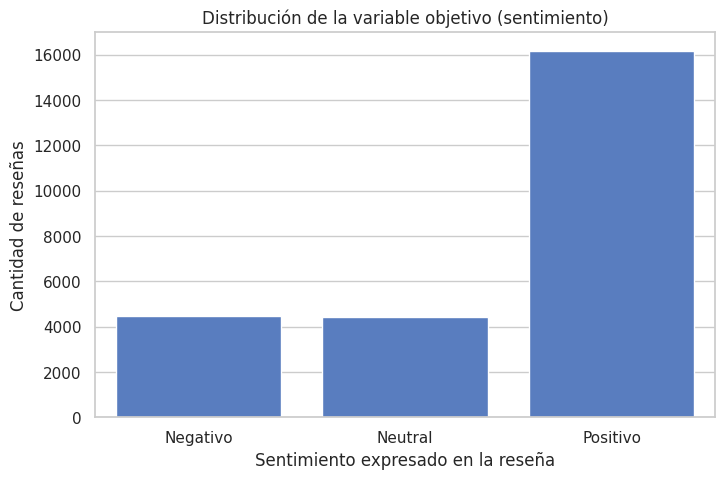

sentimiento
Positivo    64.55
Negativo    17.87
Neutral     17.58
Name: proportion, dtype: float64

In [9]:
sns.countplot(x="sentimiento", data=df_resenas, order=["Negativo", "Neutral", "Positivo"])
plt.title("Distribución de la variable objetivo (sentimiento)")
plt.xlabel("Sentimiento expresado en la reseña")
plt.ylabel("Cantidad de reseñas")
plt.show()

df_resenas["sentimiento"].value_counts(normalize=True).mul(100).round(2)

### Longitud de las reseñas según el sentimiento

Dado que en este escenario el texto de la reseña es un atributo central, se explora si existe alguna relación entre la extensión del texto y el sentimiento expresado.

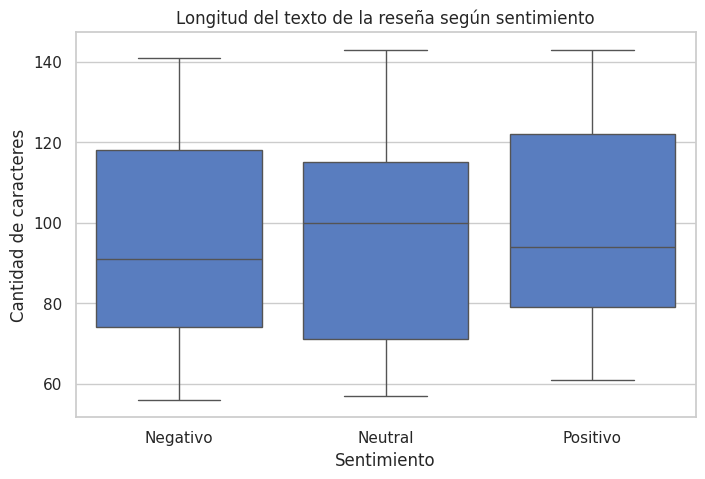

In [10]:
df_resenas["longitud_texto"] = df_resenas["texto_resena"].str.len()

sns.boxplot(x="sentimiento", y="longitud_texto", data=df_resenas, order=["Negativo", "Neutral", "Positivo"])
plt.title("Longitud del texto de la reseña según sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de caracteres")
plt.show()

# se descarta la columna auxiliar, ya que solo se utilizó para esta visualización
df_resenas.drop(columns=["longitud_texto"], inplace=True)

### Distribución de variables categóricas

Las variables categóricas permiten entender mejor la composición de los clientes y de las reseñas.


Distribución de las variables categóricas del dataset de clientes:


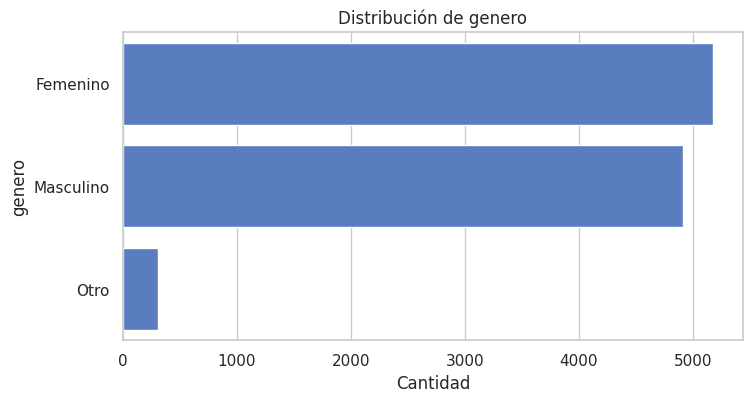

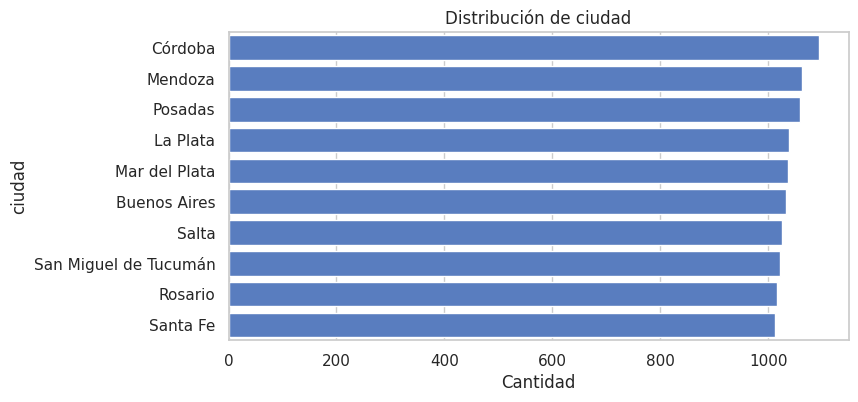

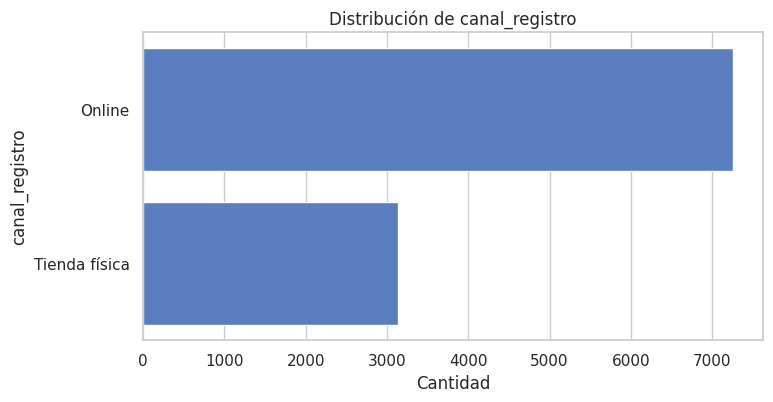

In [11]:
categorical_cols = df_clientes.select_dtypes(include=["object", "string"]).columns

print("\nDistribución de las variables categóricas del dataset de clientes:")

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df_clientes[col].value_counts().index
    sns.countplot(y=col, data=df_clientes, order=order)
    plt.title(f"Distribución de {col}")
    plt.xlabel("Cantidad")
    plt.ylabel(col)
    plt.show()


Distribución de las variables categóricas del dataset de reseñas:


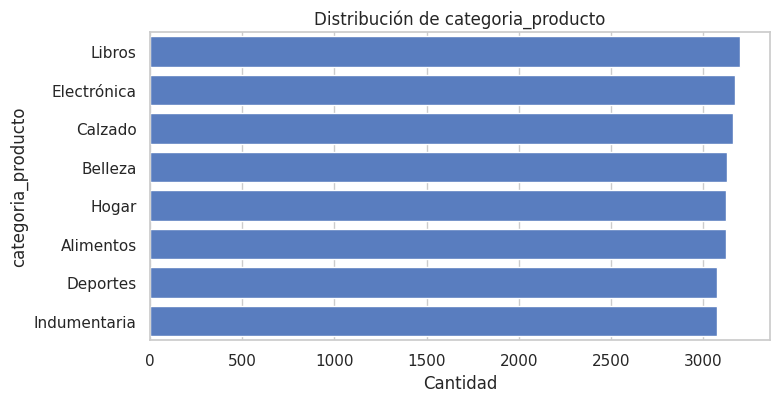

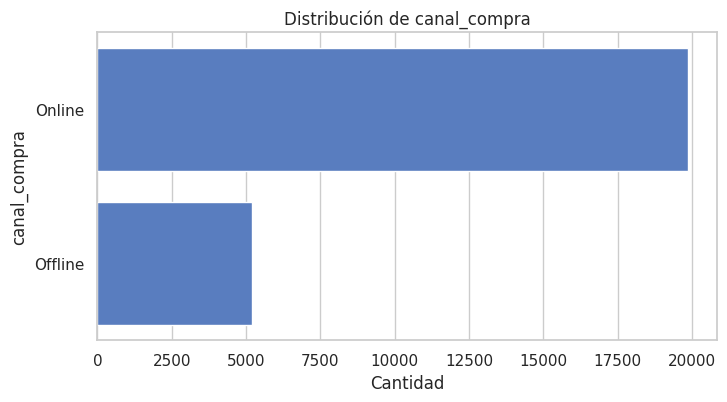

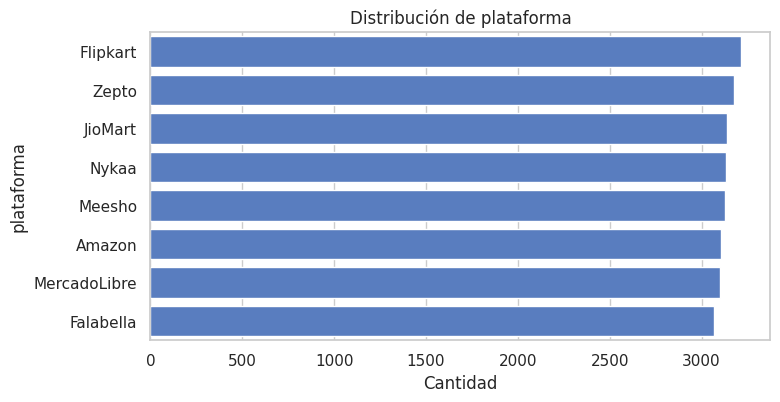

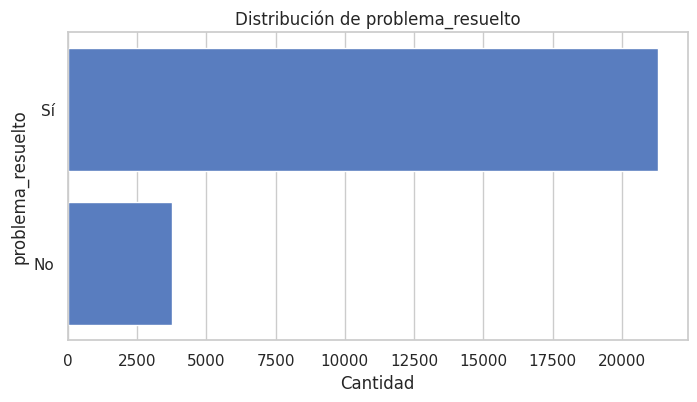

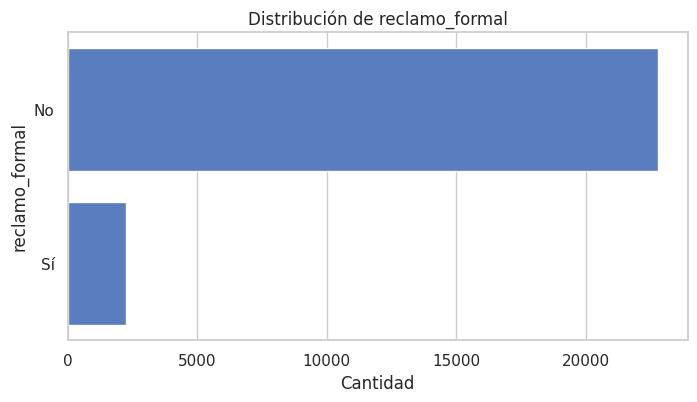

In [12]:
categorical_cols = df_resenas.select_dtypes(include=["object", "string"]).columns.drop(["texto_resena", "fecha_resena", "sentimiento"])

print("\nDistribución de las variables categóricas del dataset de reseñas:")

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df_resenas[col].value_counts().index
    sns.countplot(y=col, data=df_resenas, order=order)
    plt.title(f"Distribución de {col}")
    plt.xlabel("Cantidad")
    plt.ylabel(col)
    plt.show()

### Correlación entre variables numéricas

La correlación entre variables numéricas permite identificar relaciones lineales entre ellas y, consiguientemente, patrones que pueden ser útiles en modelos predictivos.

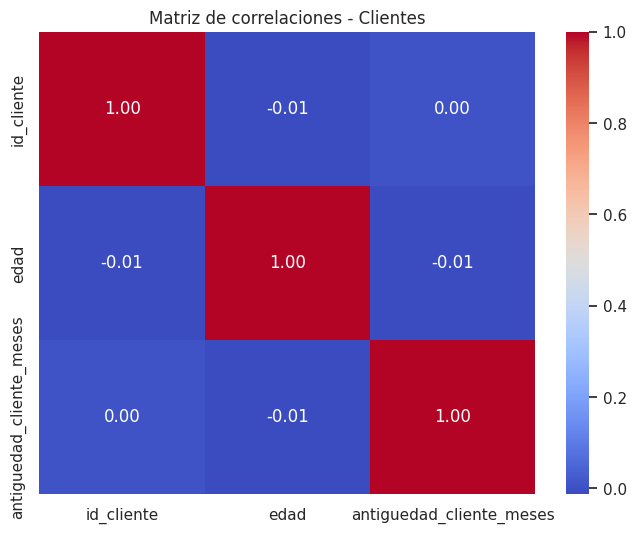

In [13]:
num_df = df_clientes.select_dtypes(include=['float64', 'int64'])
corr = num_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlaciones - Clientes')
plt.show()

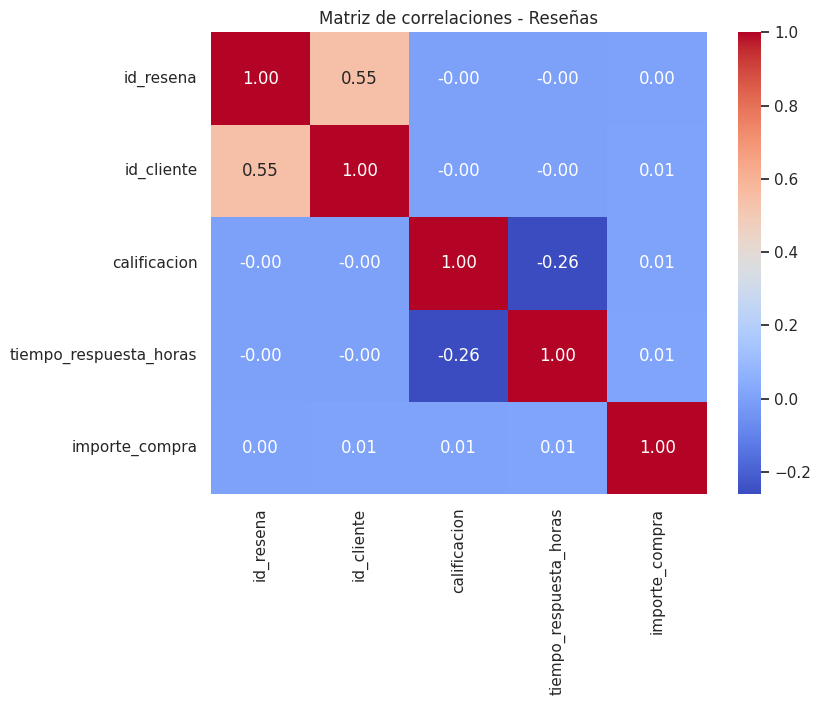

In [14]:
num_df = df_resenas.select_dtypes(include=['float64', 'int64'])
corr = num_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlaciones - Reseñas')
plt.show()

### Listado de columnas de cada dataset

Finalmente, se realiza una visualización general de las columnas de cada dataset para su registro.

In [15]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)

In [16]:
print("Descripción del dataset 'datos_clientes'")
reporte_descripcion_dataset(df_clientes)

Descripción del dataset 'datos_clientes'
Columnas del dataset:

id_cliente
edad
genero
ciudad
antiguedad_cliente_meses
canal_registro


In [17]:
print("Descripción del dataset 'datos_resenas'")
reporte_descripcion_dataset(df_resenas)

Descripción del dataset 'datos_resenas'
Columnas del dataset:

id_resena
id_cliente
categoria_producto
canal_compra
plataforma
calificacion
texto_resena
tiempo_respuesta_horas
problema_resuelto
reclamo_formal
importe_compra
fecha_resena
sentimiento
